# **CS 584-A: Natural Language Processing**
# **Homework 2**

**Name: Ankit Dhandharia**

**CWID: 20033031**

## **Goals**
The goal of HW2 is for you to get hands-on experience of implementing RNN and CNN models for the classification task. You will get a deeper understanding of how these models are applied to text data. The skills you learn from using RNN and CNN models can be applied to a wide range of NLP tasks beyond text classification. Additionally, the skills you acquire will be transferable to more advanced topics, such as attention mechanisms, transformers, and other complex architectures. Please feel free to use any packages or libraries in your implementation.




# **Task: Sentiment Analysis with Text Classification**
Based on the dataset, the task is to perform sentiment analysis, which predicts the sentiments based
on the free-text reviews. We can simplify the task as a multi-class classification problem (5 classes in total). Specifically, which are ranging from 1 to 5: highly negative, negative, neutral, positive, and highly positive.

## **Mounting Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Importing Python Libraries**

In [1]:
import numpy as np
import pandas as pd
import nltk
import string
from nltk.corpus import stopwords
import re

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## **Importing Dataset**

The dataset is about the product review dataset from Amazon. The dataset provides product reviews and overall ratings for 4,915 products. We will consider the fine-grained overall ratings as labels, which are ranging from 1 to 5: highly negative, negative, neutral, positive, and highly positive

In [59]:
dataset = pd.read_csv('drive/MyDrive/amazon_reviews.csv')
dataset

,overall,reviewText
0,4,No issues.
1,5,"Purchased this for my device, it worked as adv..."
2,4,it works as expected. I should have sprung for...
3,5,This think has worked out great.Had a diff. br...
4,5,"Bought it with Retail Packaging, arrived legit..."
...,...,...
4910,1,I bought this Sandisk 16GB Class 10 to use wit...
4911,5,Used this for extending the capabilities of my...
4912,5,Great card that is very fast and reliable. It ...
4913,5,Good amount of space for the stuff I want to d...


## **1. Data preparation**

### **1.1 Data preprocessing**
(i) converting all text to lowercase to ensure uniformity,

(ii) removing punctuations, numbers, and stopwords, and

(iii) tokenizing the reviews into tokens.

If you plan to work on the binary classification problem, you will need to assign binary class labels based on the above-mentioned strategy

In [60]:
# Tokenization and stopwords setup
stop_words = set(stopwords.words('english'))

# Initialize an empty list to store cleaned texts
cleaned_texts = []

# Loop through the dataset to clean and tokenize each text
for text in dataset["reviewText"]:
    # Convert text to lowercase and remove punctuations/numbers
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\d', '', text)

    # Tokenize the cleaned text
    words = nltk.word_tokenize(text)

    # Filter out stopwords
    tokenized_text = [word for word in words if word not in stop_words]

    # Append cleaned and tokenized text to the list
    cleaned_texts.append(tokenized_text)

# Assign the cleaned texts back to the dataframe
dataset["reviewText"] = cleaned_texts

dataset

,overall,reviewText
0,4,[issues]
1,5,"[purchased, device, worked, advertised, never,..."
2,4,"[works, expected, sprung, higher, capacity, th..."
3,5,"[think, worked, greathad, diff, bran, gb, card..."
4,5,"[bought, retail, packaging, arrived, legit, or..."
...,...,...
4910,1,"[bought, sandisk, gb, class, use, htc, inspire..."
4911,5,"[used, extending, capabilities, samsung, galax..."
4912,5,"[great, card, fast, reliable, comes, optional,..."
4913,5,"[good, amount, space, stuff, want, fits, gopro..."


### **1.2 Data split**
Split the data with the ratio of 0.8, 0.1, and 0.1 into training, validation/development, and testing, respectively

In [61]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(dataset, test_size=0.2, random_state=100) #Spliting dataset into training (80%) and remaining (20%)

val, test = train_test_split(temp, test_size=0.5, random_state=100) #Spliting the remaining 20% into validation (10%) and test (10%)

#Checking the shape of the splits to verify the ratios
print(f'Training set: {train.shape}')
print(f'Validation set: {val.shape}')
print(f'Test set: {test.shape}')

Training set: (3932, 2)
Validation set: (491, 2)
Test set: (492, 2)


### **1.3 Data statistics**
Number of data samples in training/development/testing, minimum/average/maximum/total number of tokens across all reviews in training/development/testing

In [62]:
def get_num_tokens(review_text):
    return len(str(review_text).split())

dataset_stat = {
    'Group of data': ['Training Data',
                      'Validation Data',
                      'Testing Data'],
    'Samples Data': [len(train),
                      len(val),
                      len(test)],
    'Min Token': [min(train['reviewText'].apply(get_num_tokens)),
                     min(val['reviewText'].apply(get_num_tokens)),
                     min(test['reviewText'].apply(get_num_tokens))],
    'Min 1 Reviews Tokens': [min(train['reviewText'][train['overall'] == 1].apply(get_num_tokens)),
                                         min(val['reviewText'][val['overall'] == 1].apply(get_num_tokens)),
                                         min(test['reviewText'][test['overall'] == 1].apply(get_num_tokens))],
    'Min 2 Reviews Tokens': [min(train['reviewText'][train['overall'] == 2].apply(get_num_tokens)),
                                         min(val['reviewText'][val['overall'] == 2].apply(get_num_tokens)),
                                         min(test['reviewText'][test['overall'] == 2].apply(get_num_tokens))],
    'Min 3 Reviews Tokens': [min(train['reviewText'][train['overall'] == 3].apply(get_num_tokens)),
                                         min(val['reviewText'][val['overall'] == 3].apply(get_num_tokens)),
                                         min(test['reviewText'][test['overall'] == 3].apply(get_num_tokens))],
    'Min 4 Reviews Tokens': [min(train['reviewText'][train['overall'] == 4].apply(get_num_tokens)),
                                         min(val['reviewText'][val['overall'] == 4].apply(get_num_tokens)),
                                         min(test['reviewText'][test['overall'] == 4].apply(get_num_tokens))],
    'Min 5 Reviews Tokens': [min(train['reviewText'][train['overall'] == 5].apply(get_num_tokens)),
                                         min(val['reviewText'][val['overall'] == 5].apply(get_num_tokens)),
                                         min(test['reviewText'][test['overall'] == 5].apply(get_num_tokens))],
    'Avg Tokens': [train['reviewText'].apply(get_num_tokens).mean(),
                     val['reviewText'].apply(get_num_tokens).mean(),
                     test['reviewText'].apply(get_num_tokens).mean()],
    'Avg 1 Reviews Tokens': [train['reviewText'][train['overall'] == 1].apply(get_num_tokens).mean(),
                                         val['reviewText'][val['overall'] == 1 ].apply(get_num_tokens).mean(),
                                         test['reviewText'][test['overall'] == 1].apply(get_num_tokens).mean()],
    'Avg 2 Reviews Tokens': [train['reviewText'][train['overall'] == 2].apply(get_num_tokens).mean(),
                                         val['reviewText'][val['overall'] == 2 ].apply(get_num_tokens).mean(),
                                         test['reviewText'][test['overall'] == 2].apply(get_num_tokens).mean()],
    'Avg 3 Reviews Tokens': [train['reviewText'][train['overall'] == 3].apply(get_num_tokens).mean(),
                                         val['reviewText'][val['overall'] == 3 ].apply(get_num_tokens).mean(),
                                         test['reviewText'][test['overall'] == 3].apply(get_num_tokens).mean()],
    'Avg 4 Reviews Tokens': [train['reviewText'][train['overall'] == 4].apply(get_num_tokens).mean(),
                                         val['reviewText'][val['overall'] == 4 ].apply(get_num_tokens).mean(),
                                         test['reviewText'][test['overall'] == 4].apply(get_num_tokens).mean()],
    'Avg 5 Reviews Tokens': [train['reviewText'][train['overall'] == 5].apply(get_num_tokens).mean(),
                                         val['reviewText'][val['overall'] == 5 ].apply(get_num_tokens).mean(),
                                         test['reviewText'][test['overall'] == 5].apply(get_num_tokens).mean()],
    'Max Tokens': [max(train['reviewText'].apply(get_num_tokens)),
                     max(val['reviewText'].apply(get_num_tokens)),
                     max(test['reviewText'].apply(get_num_tokens))],
    'Max 1 Reviews Tokens': [max(train['reviewText'][train['overall'] == 1].apply(get_num_tokens)),
                                         max(val['reviewText'][val['overall'] == 1].apply(get_num_tokens)),
                                         max(test['reviewText'][test['overall'] == 1].apply(get_num_tokens))],
    'Max 2 Reviews Tokens': [max(train['reviewText'][train['overall'] == 2].apply(get_num_tokens)),
                                         max(val['reviewText'][val['overall'] == 2].apply(get_num_tokens)),
                                         max(test['reviewText'][test['overall'] == 2].apply(get_num_tokens))],
    'Max 3 Reviews Tokens': [max(train['reviewText'][train['overall'] == 3].apply(get_num_tokens)),
                                         max(val['reviewText'][val['overall'] == 3].apply(get_num_tokens)),
                                         max(test['reviewText'][test['overall'] == 3].apply(get_num_tokens))],
    'Max 4 Reviews Tokens': [max(train['reviewText'][train['overall'] == 4].apply(get_num_tokens)),
                                         max(val['reviewText'][val['overall'] == 4].apply(get_num_tokens)),
                                         max(test['reviewText'][test['overall'] == 4].apply(get_num_tokens))],
    'Max 5 Reviews Tokens': [max(train['reviewText'][train['overall'] == 5].apply(get_num_tokens)),
                                         max(val['reviewText'][val['overall'] == 5].apply(get_num_tokens)),
                                         max(test['reviewText'][test['overall'] == 5].apply(get_num_tokens))],
    'Total 1 Reviews': [len(train[train['overall'] == 1]),
                           len(val[val['overall'] == 1]),
                           len(test[test['overall'] == 1])],
    'Total 2 Reviews': [len(train[train['overall'] == 2]),
                           len(val[val['overall'] == 2]),
                           len(test[test['overall'] == 2])],
    'Total 3 Reviews': [len(train[train['overall'] == 3]),
                           len(val[val['overall'] == 3]),
                           len(test[test['overall'] == 3])],
    'Total 4 Reviews': [len(train[train['overall'] == 4]),
                           len(val[val['overall'] == 4]),
                           len(test[test['overall'] == 4])],
    'Total 5 Reviews': [len(train[train['overall'] == 5]),
                           len(val[val['overall'] == 5]),
                           len(test[test['overall'] == 5])]
}

Stat_table = pd.DataFrame(dataset_stat)
Stat_table

,Group of data,Samples Data,Min Token,Min 1 Reviews Tokens,Min 2 Reviews Tokens,Min 3 Reviews Tokens,Min 4 Reviews Tokens,Min 5 Reviews Tokens,Avg Tokens,Avg 1 Reviews Tokens,...,Max 1 Reviews Tokens,Max 2 Reviews Tokens,Max 3 Reviews Tokens,Max 4 Reviews Tokens,Max 5 Reviews Tokens,Total 1 Reviews,Total 2 Reviews,Total 3 Reviews,Total 4 Reviews,Total 5 Reviews
0,Training Data,3932,1,2,7,4,1,1,25.332655,52.794872,...,781,424,210,273,544,195,65,110,420,3142
1,Validation Data,491,1,12,15,9,4,1,24.898167,60.869565,...,147,80,105,159,240,23,9,17,53,389
2,Testing Data,492,1,8,28,9,9,1,26.178862,35.153846,...,78,62,261,249,364,26,6,15,54,391


## **2. Sentiment Analysis with RNN**

Please write the code to perform the sentiment analysis task you formulated in question 1. During the implementation, you will need to follow the requirements listed below.

In [50]:
# Count-based word vectors with co-occurrence matrix

def get_vacab(corpus):

    distinct_words = []

    for i in range(len(corpus)):
        for word in corpus[i]:
            if word not in distinct_words: #Checking if the word existing in the list.
                distinct_words.append(word)

    corpus_words = sorted(distinct_words) #Sorting the list

    return corpus_words

corpus_words = get_vacab(dataset['reviewText'])
corpus_words

['aac',
 'aas',
 'aba',
 'abdroid',
 'abilities',
 'ability',
 'able',
 'aboutgood',
 'abouti',
 'abouttherehere',
 'aboutto',
 'abovei',
 'abroad',
 'abruptly',
 'absolute',
 'absolutely',
 'abt',
 'abuse',
 'abused',
 'abysmal',
 'accdientally',
 'accept',
 'acceptable',
 'acceptably',
 'accepted',
 'accepting',
 'accepts',
 'access',
 'accessed',
 'accesses',
 'accessible',
 'accessing',
 'accessories',
 'accessory',
 'accessoryalternative',
 'accident',
 'accidentally',
 'accidently',
 'acclimated',
 'accolades',
 'accommodate',
 'accomplish',
 'accord',
 'according',
 'accordingly',
 'account',
 'accros',
 'accurate',
 'accuratei',
 'accuratethe',
 'ace',
 'acer',
 'acess',
 'acheive',
 'achieve',
 'achieved',
 'achievedusing',
 'achieves',
 'acitve',
 'acknowledge',
 'acknowledged',
 'acontourroam',
 'acquire',
 'acquired',
 'acronis',
 'acronyms',
 'across',
 'act',
 'acting',
 'action',
 'actioncam',
 'activating',
 'active',
 'activity',
 'acts',
 'actual',
 'actuality',
 'act

In [11]:
#Install Keras utilities for preprocessing
!pip install keras-preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.6 MB/s eta 0:00:00


In [66]:
def split_data(dataset):
    X = dataset['reviewText']
    y = dataset['overall']

    # Split data
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=100)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=100)

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = split_data(dataset)

**1)** You can select to implement 2-layer LSTM or GRU (you can directly call packages in Pytorch).

**2)** Please use SGD during optimization.

**3)** Please initialize the word embeddings randomly and learn them during the model training.

**4)** You can decide other parameters

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


123/123 ━━━━━━━━━━━━━━━━━━━━ 56s 397ms/step - accuracy: 0.6769 - loss: 1.7334 - val_accuracy: 0.7923 - val_loss: 1.5853
Epoch 2/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 76s 349ms/step - accuracy: 0.8127 - loss: 1.5303 - val_accuracy: 0.7923 - val_loss: 1.4082
Epoch 3/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 44s 358ms/step - accuracy: 0.8000 - loss: 1.3617 - val_accuracy: 0.7923 - val_loss: 1.2536
Epoch 4/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 82s 359ms/step - accuracy: 0.8009 - loss: 1.2098 - val_accuracy: 0.7923 - val_loss: 1.1279
Epoch 5/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 79s 337ms/step - accuracy: 0.8037 - loss: 1.0845 - val_accuracy: 0.7923 - val_loss: 1.0340
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7837 - loss: 1.0477
Test Loss: 1.0297, Test Accuracy: 0.7947


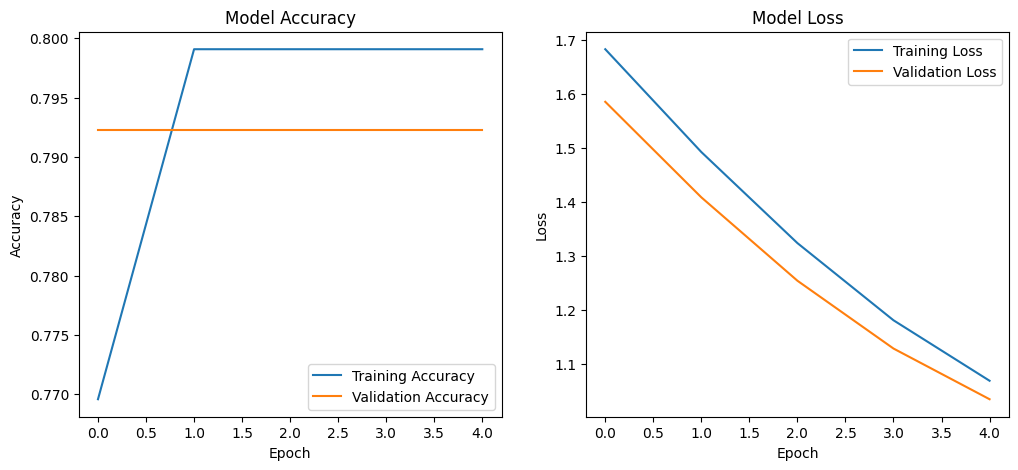

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step
Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        26
           2       0.00      0.00      0.00         6
           3       0.00      0.00      0.00        15
           4       0.00      0.00      0.00        54
           5       0.79      1.00      0.89       391

    accuracy                           0.79       492
   macro avg       0.16      0.20      0.18       492
weighted avg       0.63      0.79      0.70       492

Confusion Matrix:
[[  0   0   0   0  26]
 [  0   0   0   0   6]
 [  0   0   0   0  15]
 [  0   0   0   0  54]
 [  0   0   0   0 391]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Tokenize and pad sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
tokenizer.fit_on_texts(X_val)
tokenizer.fit_on_texts(X_test)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=200, padding='post', truncating='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=200, padding='post', truncating='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=200, padding='post', truncating='post')

# RNN function
def build_and_train_rnn(X_train, y_train, X_val, y_val, X_test, y_test):
    vocab_size = len(tokenizer.word_index) + 1
    embedding_dim = 128
    lstm_units = 20
    num_classes = 6  # Sentiment categories (1-5)
    epochs = 5

    # Define model
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=200),
        Bidirectional(LSTM(units=lstm_units, return_sequences=True)),
        Bidirectional(LSTM(units=lstm_units)),
        Dense(num_classes, activation='softmax')
    ])

    # Compile model
    model.compile(optimizer=SGD(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    # Train model
    history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_val, y_val))

    # Evaluate model
    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

    # Plot accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Predictions and evaluation
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Display metrics
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return test_accuracy

accuracy = build_and_train_rnn(X_train_seq, y_train, X_val_seq, y_val, X_test_seq, y_test)

## **3. Sentiment Analysis with CNN**

Please write the code to perform the sentiment analysis task you formulated in question 1. During the implementation, you will need to follow the requirements listed below. Feel free to use any packages and libraries.

**1)** Please use mini-batch gradient descent method during optimization with batch size 20.

**2)** Please initialize the word embeddings with the pre-trained glove embeddings you used in HW1 and update them during the model training.

**3)** You can decide other parameters.

In [54]:
import gensim.downloader as api

def load_embedding_model():
    """
    Load GloVe Vectors.

    Return:
    wv_from_bin: All 400000 embeddings, each of length 200
    """
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin

# Run the function to load GloVe word vectors
wv_from_bin = load_embedding_model()

Loaded vocab size 400000
